importing all the necessary libraries

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3


loading the dataset 

In [3]:
retail=pd.read_csv('Warehouse_and_Retail_Sales.csv')

looking into the dataset

In [10]:
retail.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [6]:
retail.shape

(307645, 9)

In [7]:
retail.describe()

,YEAR,MONTH,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
count,307645.000000,307645.000000,307642.000000,307645.000000,307645.000000
mean,2018.438525,6.423862,7.024071,6.936465,25.294597
std,1.083061,3.461812,30.986238,30.237195,249.916798
min,2017.000000,1.000000,-6.490000,-38.490000,-7800.000000
25%,2017.000000,3.000000,0.000000,0.000000,0.000000
50%,2019.000000,7.000000,0.320000,0.000000,1.000000
75%,2019.000000,9.000000,3.267500,3.000000,5.000000
max,2020.000000,12.000000,2739.000000,1990.830000,18317.000000


checking for datasets

In [8]:
retail.duplicated().sum()

np.int64(0)

checking for null values

In [15]:
retail.isna().sum()

YEAR                0
MONTH               0
SUPPLIER            0
ITEM CODE           0
ITEM DESCRIPTION    0
ITEM TYPE           0
RETAIL SALES        0
RETAIL TRANSFERS    0
WAREHOUSE SALES     0
dtype: int64

Fillling the missing values

In [14]:
retail['SUPPLIER']=retail['SUPPLIER'].fillna("Unknown")
retail['ITEM TYPE']=retail['ITEM TYPE'].fillna(retail['ITEM TYPE'].mode()[0])
retail['RETAIL SALES']=retail['RETAIL SALES'].fillna(retail['RETAIL SALES'].median())

establishing connection with mysql

In [17]:
conn=sqlite3.connect("Sales.db")

In [22]:
retail.to_sql(
    "Sales",
    conn,
    if_exists="replace",
    index=False

)

307645

In [ ]:
pd.read_sql(
    "SELECT * FROM sales LIMIT 5",
    conn
)

Using sql we are doing item sales per item type

In [27]:
query=""" 
SELECT 
    [ITEM TYPE],
    SUM([RETAIL SALES]) as Total_Sales
    FROM Sales
    GROUP BY [ITEM TYPE]
    ORDER BY Total_Sales DESC
    """
item_sales=pd.read_sql(query,conn)

item_sales

,ITEM TYPE,Total_Sales
0,LIQUOR,802691.43
1,WINE,746498.59
2,BEER,574220.53
3,NON-ALCOHOL,34085.27
4,STR_SUPPLIES,2740.88
5,REF,663.63
6,KEGS,0.00
7,DUNNAGE,0.00


ploting the graph of total sales according to item types

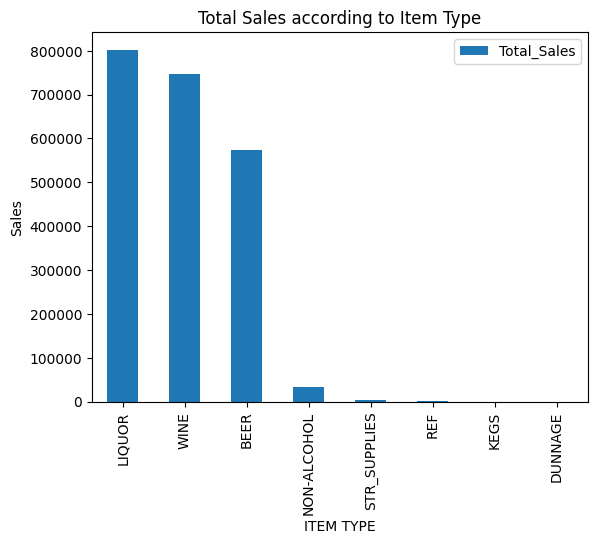

<Figure size 1600x1600 with 0 Axes>

In [32]:
item_sales.plot(x='ITEM TYPE',
                y='Total_Sales',
                kind='bar')
plt.title('Total Sales according to Item Type')
plt.ylabel('Sales')
plt.figure(figsize=(16,16))
plt.show()

with the above graph we can see that the LIQUOR,WINE,BEER are the most selled items 

With sql getting top suppliers

In [40]:
query=""" 
        SELECT
        SUPPLIER,
        SUM([RETAIL SALES]) as Total_Sales
        FROM Sales
        GROUP BY SUPPLIER
        ORDER BY Total_Sales DESC
        LIMIT 10

"""
top_supplier=pd.read_sql(query,conn)
top_supplier

,SUPPLIER,Total_Sales
0,E & J GALLO WINERY,166170.53
1,DIAGEO NORTH AMERICA INC,145343.20
2,CONSTELLATION BRANDS,131664.79
3,ANHEUSER BUSCH INC,109960.82
4,JIM BEAM BRANDS CO,96164.04
5,MILLER BREWING COMPANY,87156.44
6,CROWN IMPORTS,84437.66
7,SAZERAC CO,70414.62
8,BACARDI USA INC,66610.23
9,THE WINE GROUP,64270.04


ploting the graph of Top 10 suppliers

Text(0.5, 1.0, 'Top 10 Suppliers')

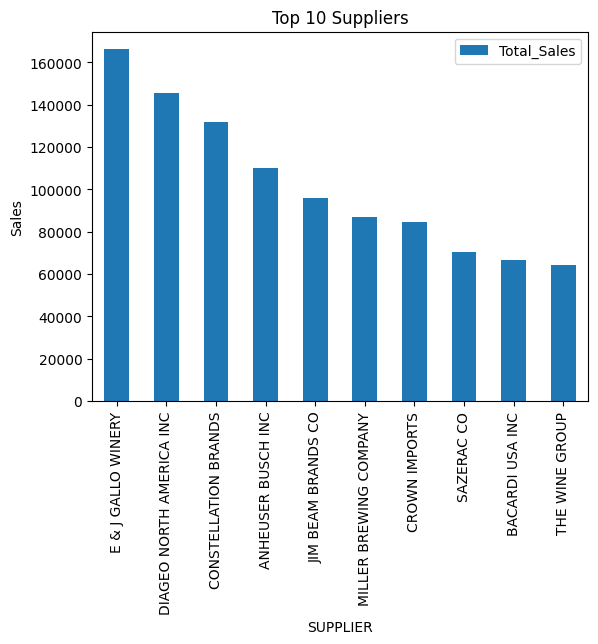

In [43]:
top_supplier.plot(x='SUPPLIER',
                  y='Total_Sales',
                  kind='bar')
plt.ylabel('Sales')
plt.title('Top 10 Suppliers')

with the help of above graph we can see top 10 suppliers
while E & J GALLO WINERY,DIAGEO NORTH AMERICA INC,CONSTELLATION BRANDS are the top 3 suppliers


Getting the sales by year

In [45]:
query=""" 
    SELECT 
     YEAR,
     SUM([RETAIL SALES]) as Total_Sales
     FROM Sales
     GROUP BY YEAR
     ORDER BY YEAR

"""
yearly_sales=pd.read_sql(query,conn)
yearly_sales

,YEAR,Total_Sales
0,2017,686734.57
1,2018,153595.90
2,2019,960191.20
3,2020,360378.66


ploting the graph of total sales per year

Text(0.5, 1.0, 'Sales Per Year')

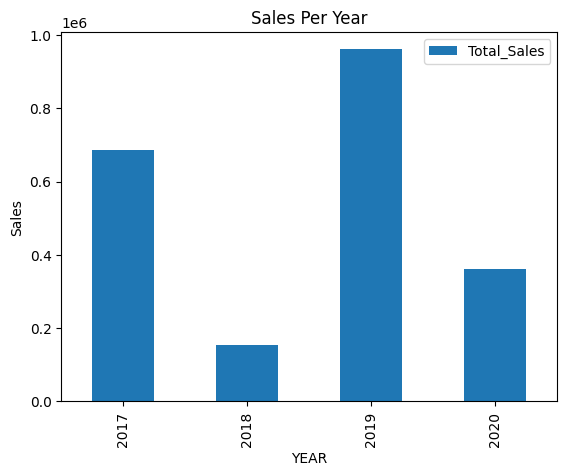

In [47]:
yearly_sales.plot(x='YEAR',
                  y='Total_Sales',
                  kind='bar')
plt.ylabel('Sales')
plt.title('Sales Per Year')

With the help of above graph we can see that 2017,2019 are the most profitable years
while 2018 having lowest sales and 2020 having below average sales

Gettnig sales per month 

In [ ]:
query = """
SELECT
    MONTH,
    SUM([RETAIL SALES]) AS Total_Sales
FROM sales
GROUP BY MONTH
ORDER BY MONTH
"""

monthly_sales = pd.read_sql(query, conn)
monthly_sales

ploting the graph for sales per monnth

Text(0.5, 1.0, 'Sales Per Month')

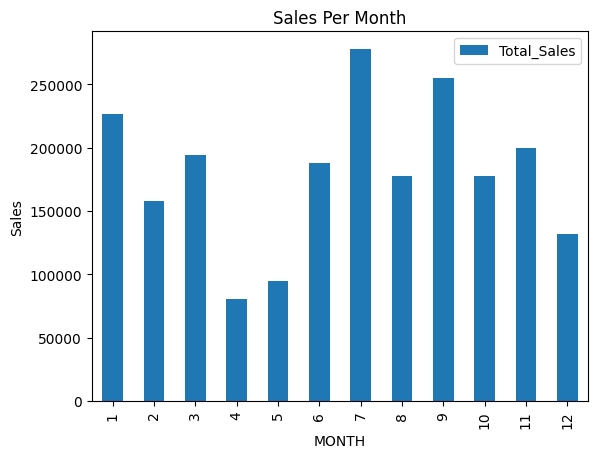

In [49]:
monthly_sales.plot(x='MONTH',
                  y='Total_Sales',
                  kind='bar')
plt.ylabel('Sales')
plt.title('Sales Per Month')

with the help of above graph we can see that 7,9,1 are the most profitable months for sales
while 4,5 months having less sales

Geting averages sales per item

In [51]:
query=""" 
    SELECT
    [ITEM TYPE],
    AVG([RETAIL SALES]) AS Avg_Sales
    FROM Sales
    GROUP BY [ITEM TYPE]
    ORDER BY  Avg_Sales DESC

"""

avg_Sales=pd.read_sql(query,conn)
avg_Sales

,ITEM TYPE,Avg_Sales
0,NON-ALCOHOL,17.864397
1,BEER,13.538786
2,LIQUOR,12.366221
3,STR_SUPPLIES,6.767605
4,REF,5.225433
5,WINE,3.978334
6,KEGS,0.000000
7,DUNNAGE,0.000000


ploting the graph for it

Text(0.5, 1.0, 'Avg  Sales')

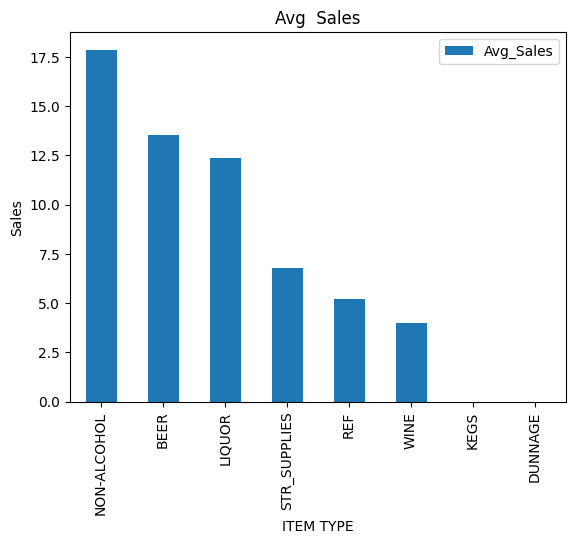

In [54]:
avg_Sales.plot(x='ITEM TYPE',
                  y='Avg_Sales',
                  kind='bar')
plt.ylabel('Sales')
plt.title('Avg  Sales')

From the above graph we can see that the average sales ofr NON-ALCOHOL,BEER and LIQUOR are very good

getting prodeuct count per item 

In [55]:
query = """
SELECT
    [ITEM TYPE],
    COUNT(*) AS Product_Count
FROM sales
GROUP BY [ITEM TYPE]
ORDER BY Product_Count DESC
"""

product_count = pd.read_sql(query, conn)
product_count

,ITEM TYPE,Product_Count
0,WINE,187641
1,LIQUOR,64910
2,BEER,42413
3,KEGS,10146
4,NON-ALCOHOL,1908
5,STR_SUPPLIES,405
6,REF,127
7,DUNNAGE,95


ploting the graph

Text(0.5, 1.0, 'Product count per item type')

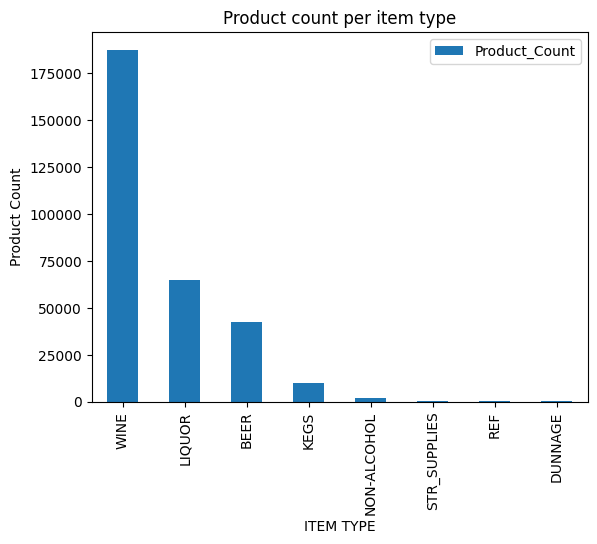

In [65]:
product_count.plot(x='ITEM TYPE',
                  y='Product_Count',
                  kind='bar')
plt.ylabel('Product Count')
plt.title('Product count per item type')

from the above graph we can see that the wine has the highest product count that means vine is in demand

now appying a machine learning mode 
it is an regression problem because target has continious values 
for this i am gonna use random forest machine learning mode which i good for large dataset like this one

the target

In [66]:
y=retail["RETAIL SALES"]

In [68]:
X=retail.drop("RETAIL SALES",axis=1)

In [78]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X["SUPPLIER"] = le.fit_transform(X["SUPPLIER"])
X["ITEM TYPE"] = le.fit_transform(X["ITEM TYPE"])
X["ITEM DESCRIPTION"] = le.fit_transform(X["ITEM DESCRIPTION"])


In [79]:
from sklearn.preprocessing import LabelEncoder

le_item = LabelEncoder()

X["ITEM CODE"] = le_item.fit_transform(
    X["ITEM CODE"].astype(str)
)

In [80]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [81]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [82]:
y_pred=model.predict(X_test)


In [84]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.8963874775553
MAE: 1.5997041313852005


A Random Forest Regressor was trained to predict retail sales using product, supplier, transfer, and warehouse information. The model achieved an R² score of 0.896, indicating that it explained nearly 90% of the variance in retail sales. The Mean Absolute Error (MAE) was 1.60, demonstrating strong predictive performance.

In [85]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
6,RETAIL TRANSFERS,0.927890
4,ITEM DESCRIPTION,0.021475
1,MONTH,0.013471
3,ITEM CODE,0.012251
7,WAREHOUSE SALES,0.008514
5,ITEM TYPE,0.007137
2,SUPPLIER,0.005479
0,YEAR,0.003783


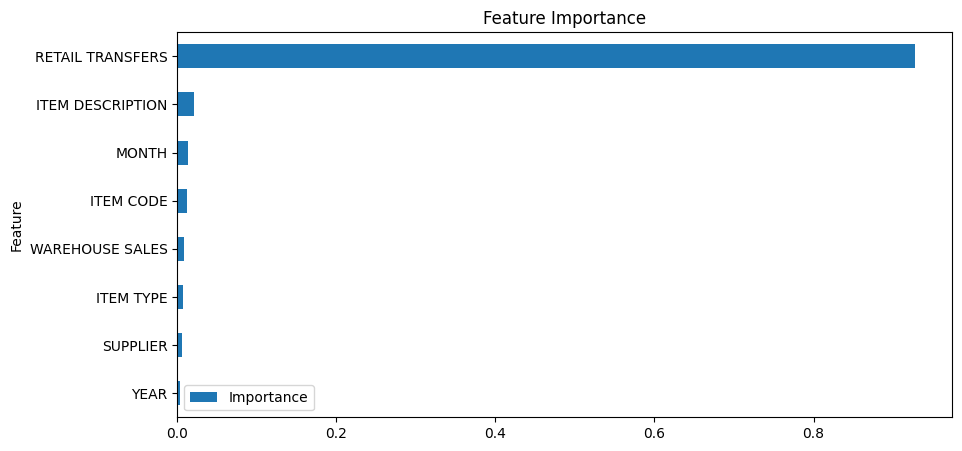

In [86]:
import matplotlib.pyplot as plt

importance = importance.sort_values(
    "Importance",
    ascending=True
)

importance.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10,5)
)

plt.title("Feature Importance")
plt.show()

This graph shows which features have the greatest influence on predicting retail sales. Retail Transfers is the most important feature, contributing about 93% of the model's predictive power, while Year and Supplier have relatively little impact

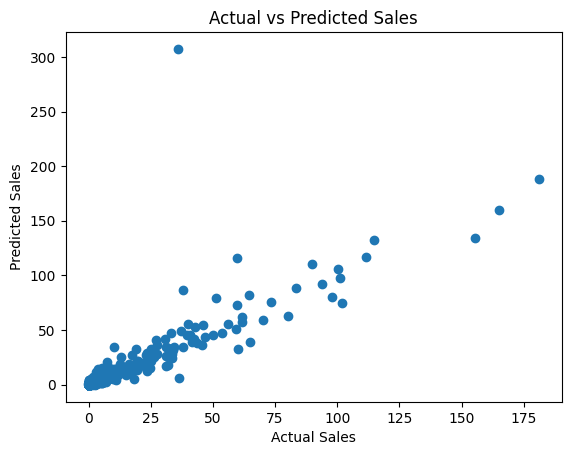

In [87]:
import matplotlib.pyplot as plt

plt.scatter(
    y_test[:1000],
    y_pred[:1000]
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

his graph compares the actual retail sales values with the values predicted by the Random Forest model. Points closer to the diagonal trend indicate accurate predictions, showing that the model performs well in estimating retail sales.